# Iambic Tetrameter HMM

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mvonebers/metrical-hmm/blob/main/notebooks/tetrameter.ipynb)

This notebook explores the belief geometry of iambic tetrameter (da-DUM da-DUM da-DUM da-DUM).

Belief lives on 7-simplex

In [ ]:
import plotly.io as pio
import sys
pio.renderers.default = "colab" if "google.colab" in sys.modules else "notebook"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

from metrical_hmm.hmm import GeneralizedMetricalHMM, GeneralizedBinaryEmission
from metrical_hmm.visualization import (
    plot_belief_trajectory_2d,
    plot_state_marginals,
    plot_belief_trajectory_pca_3d_interactive,
    plot_multiple_trajectories_pca_3d_interactive,
    plot_state_marginals_grouped,
    create_animation_generalized,
)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

import sys
sys.path.insert(0, '..')

from metrical_hmm.hmm import GeneralizedMetricalHMM, GeneralizedBinaryEmission
from metrical_hmm.visualization import (
    plot_belief_trajectory_2d,
    plot_state_marginals,
    plot_belief_trajectory_pca_3d_interactive,
    plot_multiple_trajectories_pca_3d_interactive,
    plot_state_marginals_grouped,
    create_animation_generalized,
)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Create Tetrameter HMM

Tetrameter = 4 feet per line = 8 metrical positions per line.

In [3]:
hmm = GeneralizedMetricalHMM(
    feet_per_line=4,
    strictness=0.9,
    allow_skips=True,
    line_reset_prob=0.85
)

print(hmm)
print(f"\nStates: {hmm.state_names}")
print(f"\nTransition matrix shape: {hmm.A.shape}")
print(f"Ergodic: {hmm.is_ergodic()}")
print(f"\nStationary distribution:")
for name, prob in zip(hmm.state_names, hmm.stationary_distribution()):
    print(f"  {name}: {prob:.3f}")

GeneralizedMetricalHMM(meter='tetrameter', n_states=8, strictness=0.90)

States: ['W1', 'S1', 'W2', 'S2', 'W3', 'S3', 'W4', 'S4']

Transition matrix shape: (8, 8)
Ergodic: True

Stationary distribution:
  W1: 0.121
  S1: 0.123
  W2: 0.124
  S2: 0.125
  W3: 0.126
  S3: 0.127
  W4: 0.127
  S4: 0.128


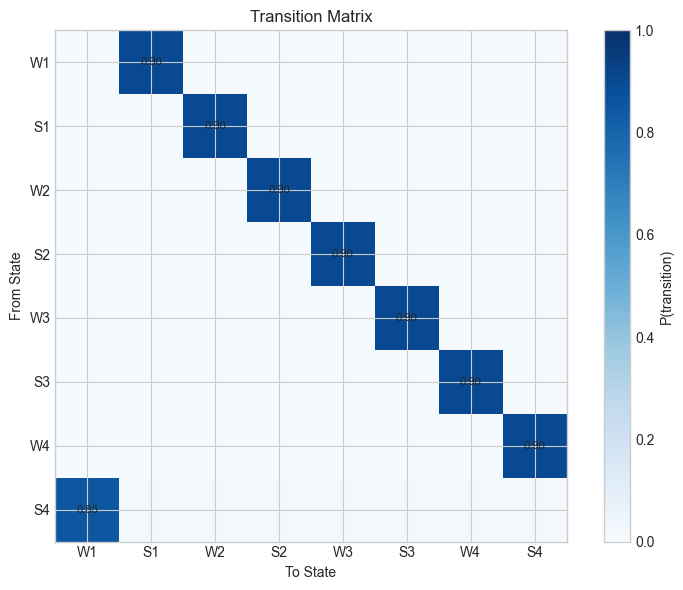

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(hmm.A, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(8))
ax.set_yticks(range(8))
ax.set_xticklabels(hmm.state_names)
ax.set_yticklabels(hmm.state_names)
ax.set_xlabel('To State')
ax.set_ylabel('From State')
ax.set_title('Transition Matrix')
plt.colorbar(im, label='P(transition)')

for i in range(8):
    for j in range(8):
        val = hmm.A[i, j]
        if val > 0.05:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Generate Sample Sequence

In [6]:
# Generate a sequence (enough for ~10 lines of tetrameter)
states, observations = hmm.sample(80, seed=42)

obs_names = ['u', 'S']  # unstressed, Stressed
obs_str = [obs_names[o] for o in observations]

print("Generated tetrameter sequence:")
print("Expected pattern: u S u S u S u S | u S u S u S u S | ...")
print()

# Format as lines of 8
positions_per_line = hmm.n_states
for i in range(0, len(obs_str), positions_per_line):
    line = '  '.join(obs_str[i:i+positions_per_line])
    state_line = ' '.join([hmm.state_names[s] for s in states[i:i+positions_per_line]])
    print(f"Line {i//positions_per_line + 1:2d}: {line}")
    print(f"         {state_line}")
    print()

Generated tetrameter sequence:
Expected pattern: u S u S u S u S | u S u S u S u S | ...

Line  1: u  S  S  S  u  S  u  S
         W1 S1 W2 S2 W3 S3 W4 S4

Line  2: u  S  u  S  u  u  u  S
         W1 S1 W2 S3 W4 S4 W1 S1

Line  3: u  S  u  S  u  S  u  S
         W2 S2 W3 S3 W4 S4 W1 S1

Line  4: u  u  u  S  u  u  u  S
         W2 S2 W3 S3 W4 S4 W1 S1

Line  5: u  S  u  S  u  u  S  u
         W2 S2 W2 S2 W3 W3 S3 W4

Line  6: S  u  u  u  S  u  S  u
         S4 W1 S1 W2 S2 W3 S3 W4

Line  7: u  S  S  S  S  u  S  u
         S4 W1 S1 W2 S2 W3 S3 W4

Line  8: S  S  S  u  S  u  u  u
         S4 W1 S1 W2 S2 W3 W2 S2

Line  9: u  S  u  u  u  u  u  S
         W3 S3 W4 S4 W4 S4 W1 S2

Line 10: u  S  u  S  u  S  u  S
         W3 S3 W4 S4 W1 S1 W2 S2



## 3. Compute Belief Trajectory

In [7]:
# Compute beliefs
beliefs = hmm.forward(observations)

print(f"Belief shape: {beliefs.shape}")
print(f"\nFirst line of beliefs (t=0 to t=7):")
print("t   | " + " ".join([f"{name:>5s}" for name in hmm.state_names]) + " | obs | true")
print("-" * 75)
for t in range(8):
    b = beliefs[t]
    b_str = " ".join([f"{p:5.2f}" for p in b])
    print(f"{t:3d} | {b_str} |  {obs_names[observations[t]]}  | {hmm.state_names[states[t]]}")

Belief shape: (80, 8)

First line of beliefs (t=0 to t=7):
t   |    W1    S1    W2    S2    W3    S3    W4    S4 | obs | true
---------------------------------------------------------------------------
  0 |  0.96  0.00  0.01  0.00  0.01  0.00  0.01  0.00 |  u  | W1
  1 |  0.00  0.91  0.00  0.03  0.00  0.03  0.00  0.03 |  S  | S1
  2 |  0.03  0.07  0.62  0.07  0.03  0.07  0.03  0.07 |  S  | W2
  3 |  0.02  0.05  0.02  0.76  0.02  0.05  0.02  0.05 |  S  | S2
  4 |  0.07  0.01  0.07  0.01  0.77  0.01  0.07  0.01 |  u  | W3
  5 |  0.00  0.08  0.00  0.08  0.00  0.75  0.00  0.08 |  S  | S3
  6 |  0.09  0.00  0.09  0.00  0.09  0.00  0.72  0.00 |  u  | W4
  7 |  0.00  0.10  0.00  0.10  0.00  0.10  0.00  0.69 |  S  | S4


## Visualize Belief Trajectory with 3D PCA


In [8]:
fig = plot_belief_trajectory_pca_3d_interactive(
    beliefs,
    state_names=hmm.state_names,
    title="Tetrameter Belief Trajectory (PCA 3D)"
)
fig

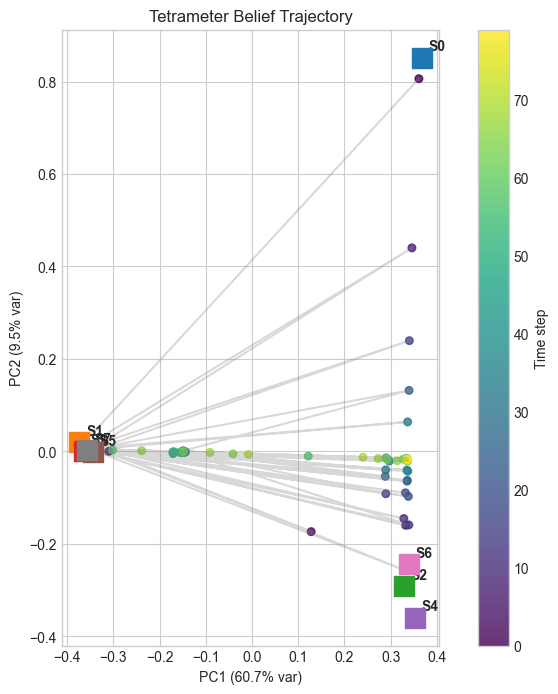

In [10]:
# 2D PCA projection
fig, ax = plot_belief_trajectory_2d(
    beliefs, 
    title="Tetrameter Belief Trajectory",
    figsize=(10, 8)
)
plt.show()

In [12]:
strictness_levels = [0.7, 0.85, 0.95]
belief_lists_by_strictness = []
labels = []

for s in strictness_levels:
    hmm_s = GeneralizedMetricalHMM(feet_per_line=4, strictness=s, allow_skips=True)
    _, obs = hmm_s.sample(80, seed=42)
    belief_lists_by_strictness.append(hmm_s.forward(obs))
    labels.append(f'Strictness={s}')

fig = plot_multiple_trajectories_pca_3d_interactive(
    belief_lists_by_strictness,
    state_names=hmm.state_names,
    labels=labels,
    title="Strictness Comparison (Tetrameter)"
)
fig

## Animation

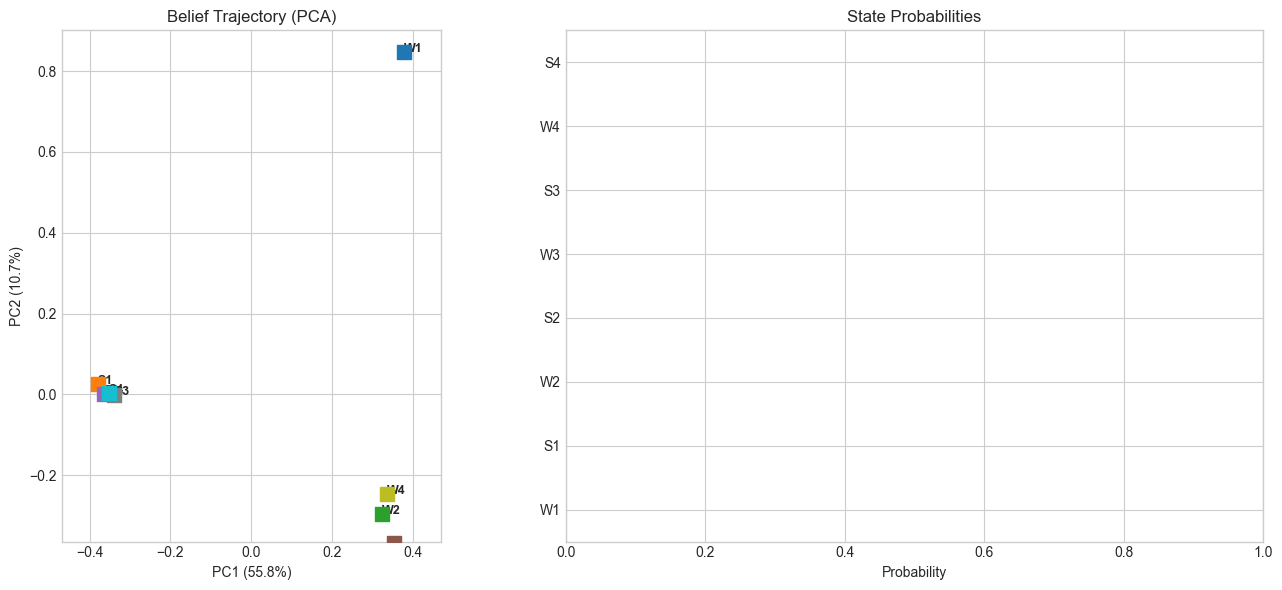

In [15]:
states, obs = hmm.sample(64, seed=42)  # 8 lines of tetrameter
beliefs = hmm.forward(obs)

anim = create_animation_generalized(
    beliefs,
    hmm.state_names,
    observations=obs,
    interval=150
)
HTML(anim.to_jshtml())